# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


- El dataset contiene 40,000 registros y 9 columnas, lo cual indica un tamaño adecuado para aplicar pruebas estadísticas con buena potencia.
- No se observan valores ausentes en ninguna columna (todas tienen 40,000 non-null). Esto indica buena calidad inicial de los datos y no es necesario realizar imputaciones o eliminaciones por datos faltantes.
- Tipos de datos:
    - user_id → object (correcto, es un identificador)
    - date → object (debería ser tipo datetime)
    - landing, region, dispositivo, traffic_source, user_type → object (correcto, son variables categóricas)
    - converted → int64 (correcto, variable binaria 0/1)
    - gasto → float64 (correcto, variable numérica continua)
- La columna date está como tipo object y debería convertirse a formato datetime para permitir análisis temporal si fuera necesario.

In [5]:
df['date'] = pd.to_datetime(df['date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [7]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [8]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [9]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [10]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [11]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [12]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df['landing'].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64


- La variable landing contiene únicamente las dos categorías esperadas del experimento: A y B.
- La distribución es prácticamente balanceada (A: 19,982, B: 20,018), lo que indica que el experimento fue correctamente asignado y no presenta desbalance significativo entre grupos.
- No se observan categorías mal escritas ni valores inesperados.
- Se puede continuar con el análisis del experimento.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [13]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba de hipótesis – Comparación de gasto promedio

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los usuarios convertidos es igual en la página A y la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de los usuarios convertidos es diferente entre la página A y la página B

In [15]:
# Aplicar prueba
from scipy import stats

stat, p_value = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico : {stat:.4f}")
print(f"Valor p: {p_value:.4f}")

Estadístico : -9.4810
Valor p: 0.0000


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀), ya que el valor p es significativamente menor a 0.05.
Existe evidencia estadística suficiente para afirmar que el gasto promedio entre la página A y la página B es diferente.

**Interpretación de negocio:**  
Los resultados indican que la versión B genera un gasto promedio significativamente mayor por usuario convertido en comparación con la versión A. Esto significa que, además de convertir usuarios, la página B está logrando que los clientes que compran gasten más dinero. Desde una perspectiva de negocio, la versión B no solo impacta la conversión, sino también el valor económico generado por cada cliente, lo cual es un indicador clave para maximizar ingresos.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba de hipótesis – Comparación de tasa de conversión

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre la página A y la página B.

In [16]:
# Número de usuarios convertidos por página
convertidos = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [17]:
# Aplicar prueba
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
tabla = pd.crosstab(df['landing'], df['converted'])

# Aplicar prueba chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla)

# Visualizar resultados
print(f"Estadístico : {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")

Estadístico : 93.3748
Valor p: 0.0000


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀), ya que el valor p es significativamente menor a 0.05.
Existe evidencia estadística suficiente para afirmar que la tasa de conversión no es igual entre la página A y la página B.

**Interpretación de negocio:**  
El resultado indica que la versión B presenta una tasa de conversión significativamente mayor que la versión A. Esto significa que la página B logra que una mayor proporción de usuarios realice una compra. La diferencia observada no se debe al azar, sino que refleja un impacto real del diseño o contenido de la versión B sobre el comportamiento de los usuarios. Desde una perspectiva estratégica, la versión B no solo genera más conversiones en términos absolutos, sino que mejora la probabilidad de compra por usuario, lo que la convierte en una opción más efectiva para implementar como versión definitiva de la página de inicio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba de hipótesis – Fuente de tráfico vs Conversión

**Hipótesis:**
- **Hipótesis nula (H₀):** La conversión es independiente de la fuente de tráfico. (No existe asociación entre `traffic_source` y `converted`).
- **Hipótesis alternativa (H₁):** La conversión depende de la fuente de tráfico. (Existe asociación entre `traffic_source` y `converted`).

In [18]:
# Aplicar prueba
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
tabla_trafico = pd.crosstab(df['traffic_source'], df['converted'])

# Aplicar prueba Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_trafico)

# Visualizar resultados
print(f"Estadístico: {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")

Estadístico: 8.6621
Valor p: 0.0341


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀), ya que el valor p (0.0341) es menor a 0.05. Existe evidencia estadísticamente significativa de que la conversión no es independiente de la fuente de tráfico.

**Interpretación de negocio:**  
Los resultados indican que la fuente de tráfico influye en la probabilidad de conversión. Esto significa que no todos los canales generan el mismo desempeño en términos de ventas. 
Al analizar tanto las cantidades absolutas como las tasas de conversión:
- Las cantidades absolutas muestran qué canal aporta más conversiones en volumen.
- Las tasas de conversión permiten identificar qué canal es más eficiente (mayor proporción de usuarios que compran).

Desde una perspectiva estratégica, esto implica que la empresa puede optimizar la inversión en marketing, priorizando los canales con mayor tasa de conversión y evaluando ajustes en aquellos con menor rendimiento. Esto permite mejorar el retorno sobre la inversión publicitaria (ROI) y maximizar ingresos.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba de hipótesis – Tipo de usuario vs Conversión

**Hipótesis:**
- **Hipótesis nula (H₀):** La conversión es independiente del tipo de usuario. (No existe asociación entre `user_type` y `converted`).
- **Hipótesis alternativa (H₁):** La conversión depende del tipo de usuario.
(Existe asociación entre `user_type` y `converted`).

In [19]:
# Aplicar prueba
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])

# Aplicar prueba Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_usuario)

# Visualizar resultados
print(f"Estadístico: {chi2:.4f}")
print(f"Valor p: {p_value:.4f}")

Estadístico: 0.5135
Valor p: 0.4736


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula (H₀), ya que el valor p (0.4736) es mayor a 0.05. No existe evidencia estadísticamente significativa para afirmar que la conversión dependa del tipo de usuario.

**Interpretación de negocio:**  
Los resultados indican que, en el contexto del experimento analizado, los usuarios nuevos y los usuarios recurrentes presentan tasas de conversión similares. Esto sugiere que el desempeño de la página no está influenciado de manera significativa por el tipo de usuario. Por lo tanto, no hay evidencia que justifique una estrategia diferenciada basada únicamente en si el usuario es nuevo o recurrente. Desde una perspectiva estratégica, la empresa debería enfocar sus esfuerzos de optimización en factores que sí mostraron impacto significativo, como la versión de la landing page y los canales de tráfico, en lugar de segmentar por tipo de usuario en este caso específico.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

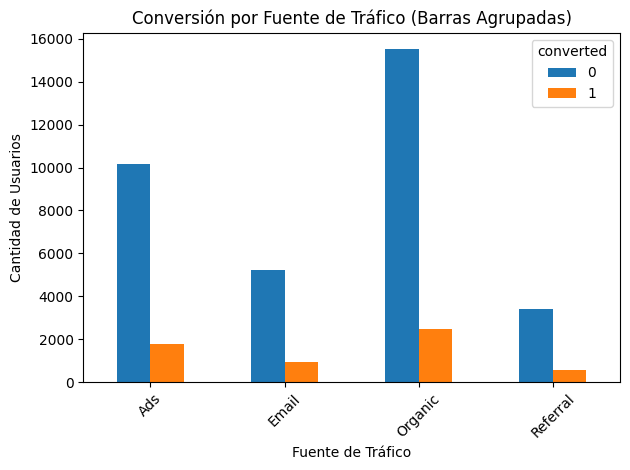

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Tabla de contingencia
tabla_trafico = pd.crosstab(df['traffic_source'], df['converted'])

# Barras agrupadas
tabla_trafico.plot(kind='bar')

plt.title("Conversión por Fuente de Tráfico (Barras Agrupadas)")
plt.xlabel("Fuente de Tráfico")
plt.ylabel("Cantidad de Usuarios")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Organic presenta el mayor volumen total de usuarios y también el mayor número absoluto de conversiones.
- Ads es la segunda fuente con más conversiones en términos absolutos.
- Email y Referral muestran menor volumen y menor cantidad de conversiones.

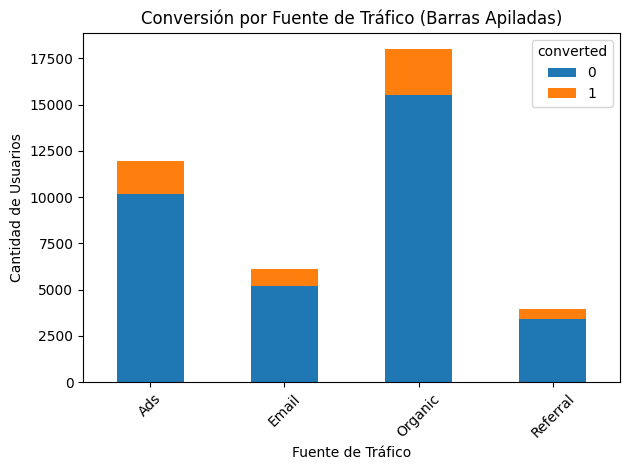

In [22]:
tabla_trafico.plot(kind='bar', stacked=True)

plt.title("Conversión por Fuente de Tráfico (Barras Apiladas)")
plt.xlabel("Fuente de Tráfico")
plt.ylabel("Cantidad de Usuarios")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Aunque Organic tiene más conversiones en términos absolutos, la proporción de convertidos respecto al total parece similar entre canales.
- No se observan diferencias visuales extremadamente marcadas en la tasa relativa.
- Ads y Email parecen mantener proporciones competitivas respecto a su tamaño.

### Relación entre el tipo de usuario y la conversión

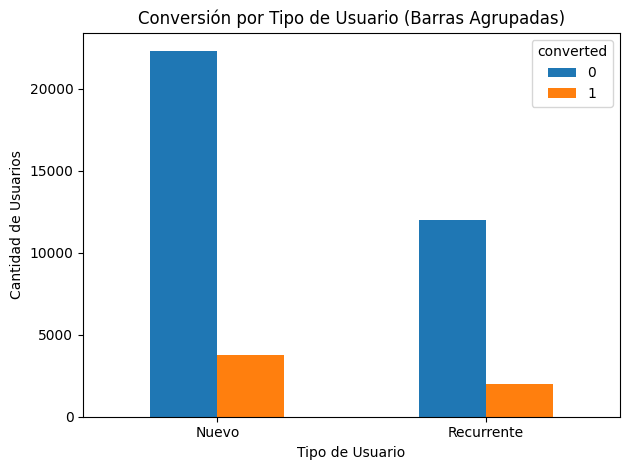

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Tabla de contingencia
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])

# Barras agrupadas
tabla_usuario.plot(kind='bar')

plt.title("Conversión por Tipo de Usuario (Barras Agrupadas)")
plt.xlabel("Tipo de Usuario")
plt.ylabel("Cantidad de Usuarios")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- Los usuarios nuevos presentan mayor volumen total y mayor número absoluto de conversiones.
- Los usuarios recurrentes convierten en menor cantidad absoluta.

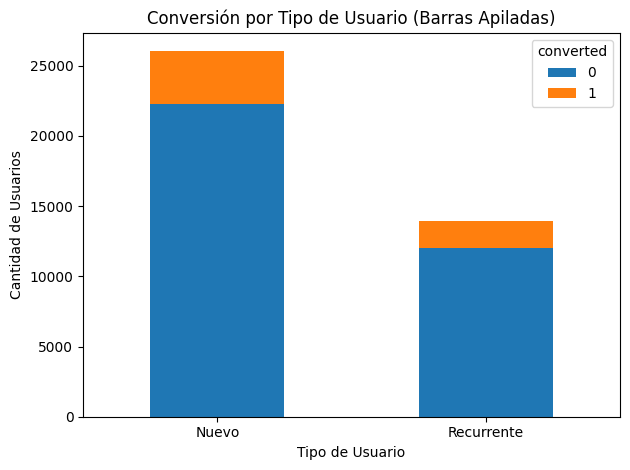

In [24]:
tabla_usuario.plot(kind='bar', stacked=True)

plt.title("Conversión por Tipo de Usuario (Barras Apiladas)")
plt.xlabel("Tipo de Usuario")
plt.ylabel("Cantidad de Usuarios")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- La proporción de conversión entre nuevos y recurrentes es visualmente muy similar, aunque ligeramente mayor para nuevos usuarios.
- No se observan diferencias claras en la tasa relativa de conversión.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- **¿Qué página genera mayor conversión y gasto promedio?** La página B genera una tasa de conversión significativamente mayor que la página A 
- **¿Qué canales de tráfico son más efectivos para generar conversiones?** Organic y Ads generan el mayor volumen de conversiones. 
- **¿Existen diferencias significativas según el tipo de usuario?** Las tasas de conversión son similares entre ambos perfiles, aunque ligeramente mayor para nuevos usuarios.  
- **¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?**
    - Implementar página B como estándar.
    - Redistribuir inversión hacia los canales con mayor eficiencia.
    - Analizar costo por canal para maximizar ROI.
    - Continuar realizando pruebas A/B para optimización incremental.
    - Explorar segmentación adicional (comportamiento, demografía, dispositivo) para futuras mejoras.

---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observación 1: Se encontró una diferencia estadísticamente significativa en el gasto promedio entre la página A y la página B.
- Observación 2: La página B muestra un comportamiento de compra superior en comparación con la página A.
- **Interpretación:** La versión B no solo influye en la decisión de conversión, sino también en el valor generado por cada cliente. Esto sugiere que la experiencia, diseño o propuesta de valor presentada en la página B incentiva un mayor gasto.

**Tasa de conversión:** 
- Observación 1: La página B presenta una tasa de conversión significativamente mayor que la página A (p < 0.05).
- Observación 2: La diferencia observada no es aleatoria, sino estadísticamente sólida.
- **Interpretación:** La página B es más efectiva para transformar visitantes en clientes. Desde una perspectiva de negocio, representa una mejora directa en eficiencia comercial.

---

#### 📊 **Segmentación por fuente de tráfico**
- Observación: Se identificó una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (p = 0.0341). Las fuentes con mayor volumen (Organic y Ads) generan más conversiones, aunque la efectividad relativa varía entre canales.
- **Interpretación:** El canal de adquisición influye en la probabilidad de conversión. No todos los usuarios llegan con el mismo nivel de intención de compra, por lo que la estrategia de marketing debe considerar tanto volumen como tasa de conversión.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- Observación: No se encontraron diferencias estadísticamente significativas entre usuarios nuevos y recurrentes (p = 0.4736). Las tasas de conversión son similares entre ambos grupos.
- **Interpretación:** El tipo de usuario no determina significativamente la probabilidad de conversión en este experimento. La optimización debe centrarse más en la experiencia de página y en la fuente de tráfico que en esta segmentación.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- **Recomendación 1:** El tipo de usuario no determina significativamente la probabilidad de conversión en este experimento. La optimización debe centrarse más en la experiencia de página y en la fuente de tráfico que en esta segmentación.
- **Recomendación 2:** Optimizar la inversión en los canales de tráfico más efectivos y evaluar desempeño con métricas de eficiencia (CPA, ROI), priorizando calidad de tráfico sobre volumen.
- **Recomendación 3:** Realizar pruebas A/B adicionales sobre elementos específicos de la página B (CTA, estructura de precios, copy, diseño visual) para optimizar incrementalmente la tasa de conversión y el ticket promedio.
- **Recomendación 4:** Implementar un análisis de rentabilidad por canal (integrando costo de adquisición y valor promedio generado) para redistribuir presupuesto hacia los segmentos con mayor retorno sobre la inversión (ROI), maximizando eficiencia financiera.